In [1]:
import pandas as pd

# Load test set
test_df = pd.read_csv('../data/test_set.csv')

In [2]:
import joblib

preprocessing_data = joblib.load('../utils/preprocessing_data.pkl')

numerical_cols = preprocessing_data['numerical_cols']
categorical_cols = preprocessing_data['categorical_cols']
balanced_cols = preprocessing_data['balanced_cols']
corelated_cols = preprocessing_data['corelated_cols']
balanced_col_classes = preprocessing_data['balanced_col_classes']
iterative_imputer = preprocessing_data['iterative_imputer']
numerical_imputer = preprocessing_data['numerical_imputer']
categorical_imputer = preprocessing_data['categorical_imputer']
ohe = preprocessing_data['onehot_encoder']
scaler = preprocessing_data['scaler']
top_10_features = preprocessing_data['top_10_features']

In [3]:
import numpy as np

def random_impute(df, col, classes, seed=42):
    mask = df[col].isna()
    
    if mask.sum() == 0:
        return df
    
    rng = np.random.default_rng(seed)
    
    df.loc[mask, col] = rng.choice(
        classes,
        size=mask.sum(),
        replace=True
    )
    
    return df

In [4]:
# Impute missing values
test_df[corelated_cols] = iterative_imputer.transform(test_df[corelated_cols])
test_df[numerical_cols] = numerical_imputer.transform(test_df[numerical_cols])
test_df[categorical_cols] = categorical_imputer.transform(test_df[categorical_cols])

for col in balanced_cols:
	random_impute(test_df, col, balanced_col_classes[col])

In [5]:
# Convert target variable to numeric
test_df['Diabetes'] = test_df['Diabetes'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

In [6]:
# One-hot encode categorical variables
encoded_cat = ohe.transform(test_df[categorical_cols]).toarray()
encoded_cat_df = pd.DataFrame(encoded_cat, columns=ohe.get_feature_names_out(categorical_cols))
test_df = pd.concat([test_df.drop(columns=categorical_cols), encoded_cat_df], axis=1)

In [7]:
X_test = test_df.drop(columns=['Diabetes'])
y_test = test_df['Diabetes']

In [8]:
# Scale numeric features
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [9]:
# Select top 10 features
X_test = X_test[top_10_features]
X_test.head()

,Temperature,Height,Age,BMI,Gender_Male,Blood Type_O,Cholesterol,Heart Rate,Weight,Blood Type_AB
0,-0.000261,1.283600,-1.297873,-1.631546,1.0,0.0,0.000318,0.000225,-1.469458,1.0
1,0.452734,1.267036,-1.297873,-0.419929,1.0,0.0,-0.405975,0.501210,0.355790,0.0
2,-1.000806,-1.695277,1.718244,0.522694,1.0,0.0,1.388813,0.000225,-0.501506,0.0
3,0.061050,-0.387087,0.210185,0.863284,1.0,0.0,1.276639,0.000225,0.830473,0.0
4,0.206713,-1.635969,0.425622,2.270831,1.0,0.0,0.000318,-1.324267,1.161638,0.0


In [10]:
# Load Hyper-parameters
hyperparams = joblib.load('../utils/hyperparameters.pkl')

model_type = hyperparams['model_type']

input_size = hyperparams['input_size']
hidden_size = hyperparams['hidden_size']
num_classes = hyperparams['num_classes']
size_factor = hyperparams['size_factor']
dropout_rate = hyperparams['dropout_rate']

batch_size = hyperparams['batch_size']

In [11]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Data loaders
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [12]:
import torch.nn as nn

# Architecture 1: 2 hidden layers (Relu + Dropout)
class NeuralNet1(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, size_factor, dropout_rate):
        super(NeuralNet1, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)

        self.fc2 = nn.Linear(hidden_size, hidden_size // size_factor)

        self.fc3 = nn.Linear(hidden_size // size_factor, num_classes - 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.dropout(out)

        out = self.relu(self.fc2(out))
        out = self.dropout(out)

        out = self.fc3(out)  # No activation here, BCEWithLogitsLoss handles it
        return out
    
# Architecture 2: 2 hidden layers (Relu + Dropout + BatchNorm)
class NeuralNet2(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, size_factor, dropout_rate):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.fc2 = nn.Linear(hidden_size, hidden_size // size_factor)
        self.bn2 = nn.BatchNorm1d(hidden_size // size_factor)

        self.fc3 = nn.Linear(hidden_size // size_factor, num_classes - 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.bn1(self.relu(self.fc1(x)))
        out = self.dropout(out)

        out = self.bn2(self.relu(self.fc2(out)))
        out = self.dropout(out)

        out = self.fc3(out)  # No activation here, BCEWithLogitsLoss handles it
        return out


# Architecture 3: 3 hidden layers (Relu + Dropout)
class NeuralNet3(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, size_factor, dropout_rate):
        super(NeuralNet3, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)

        self.fc2 = nn.Linear(hidden_size, hidden_size // size_factor)

        self.fc3 = nn.Linear(hidden_size // size_factor, hidden_size // (size_factor ** 2))

        self.fc4 = nn.Linear(hidden_size // (size_factor ** 2), num_classes - 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.dropout(out)

        out = self.relu(self.fc2(out))
        out = self.dropout(out)

        out = self.relu(self.fc3(out))
        out = self.dropout(out)

        out = self.fc4(out)  # No activation here, BCEWithLogitsLoss handles it
        return out
    
# Architecture 4: 3 hidden layers (Relu + Dropout + BatchNorm)
class NeuralNet4(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, size_factor, dropout_rate):
        super(NeuralNet4, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.fc2 = nn.Linear(hidden_size, hidden_size // size_factor)
        self.bn2 = nn.BatchNorm1d(hidden_size // size_factor)

        self.fc3 = nn.Linear(hidden_size // size_factor, hidden_size // (size_factor ** 2))
        self.bn3 = nn.BatchNorm1d(hidden_size // (size_factor ** 2))

        self.fc4 = nn.Linear(hidden_size // (size_factor ** 2), num_classes - 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.bn1(self.relu(self.fc1(x)))
        out = self.dropout(out)

        out = self.bn2(self.relu(self.fc2(out)))
        out = self.dropout(out)

        out = self.bn3(self.relu(self.fc3(out)))
        out = self.dropout(out)

        out = self.fc4(out)  # No activation here, BCEWithLogitsLoss handles it
        return out

In [13]:
# Initialize model (choose architecture)
if model_type == 'NeuralNet1':
	model = NeuralNet1(input_size, hidden_size, num_classes, size_factor, dropout_rate).to(device)
elif model_type == 'NeuralNet2':
	model = NeuralNet2(input_size, hidden_size, num_classes, size_factor, dropout_rate).to(device)
elif model_type == 'NeuralNet3':
	model = NeuralNet3(input_size, hidden_size, num_classes, size_factor, dropout_rate).to(device)
elif model_type == 'NeuralNet4':
	model = NeuralNet4(input_size, hidden_size, num_classes, size_factor, dropout_rate).to(device)

In [14]:
# Load best model
best_model_path = '../models/best_model.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

NeuralNet2(
  (fc1): Linear(in_features=10, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (bn2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=1024, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [15]:
# Evaluate on test set
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(features)
        
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_prob.extend(probs.flatten())
        y_true.extend(labels.cpu().numpy().flatten())

# ---------- Threshold selection ----------
threshold = 0.5  # baseline
y_pred = (np.array(y_prob) > threshold).astype(int)

# ---------- Metrics ----------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred)
auroc = roc_auc_score(y_true, y_prob)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'AUROC    : {auroc:.4f}')

Accuracy : 0.8333
Precision: 0.1994
F1-Score : 0.2091
AUROC    : 0.6157


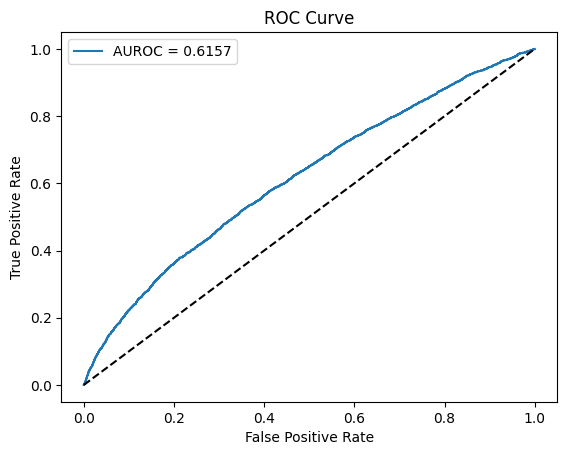

In [16]:
# AUROC Curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUROC = {auroc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [17]:
# Check class distribution in test set
print("Test set class distribution:")
print(y_test.value_counts(normalize=True))

# Quick prediction check (first batch)
with torch.no_grad():
    features, labels = next(iter(test_loader))
    features = features.to(device)
    outputs = model(features)
    probs = torch.sigmoid(outputs).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    print("Sample probability (first 10):", probs.flatten()[:10])
    print("Sample predictions (first 10):", preds.flatten()[:10])
    print("Sample true labels (first 10):", labels.cpu().numpy().flatten()[:10])

Test set class distribution:
Diabetes
0    0.89976
1    0.10024
Name: proportion, dtype: float64
Sample probability (first 10): [0.15963367 0.07684954 0.03160629 0.5263182  0.7545829  0.44985947
 0.3484664  0.03387985 0.22412969 0.01843844]
Sample predictions (first 10): [0 0 0 1 1 0 0 0 0 0]
Sample true labels (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [18]:
# Load best model
best_model_path = '../models/final_model.pth'
model.load_state_dict(torch.load(best_model_path))
model.eval()

NeuralNet2(
  (fc1): Linear(in_features=10, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (bn2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=1024, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [19]:
# Evaluate on test set
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(features)
        
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_prob.extend(probs.flatten())
        y_true.extend(labels.cpu().numpy().flatten())

# ---------- Threshold selection ----------
threshold = 0.5  # baseline
y_pred = (np.array(y_prob) > threshold).astype(int)

# ---------- Metrics ----------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred)
auroc = roc_auc_score(y_true, y_prob)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'AUROC    : {auroc:.4f}')

Accuracy : 0.8121
Precision: 0.2093
F1-Score : 0.2514
AUROC    : 0.6484


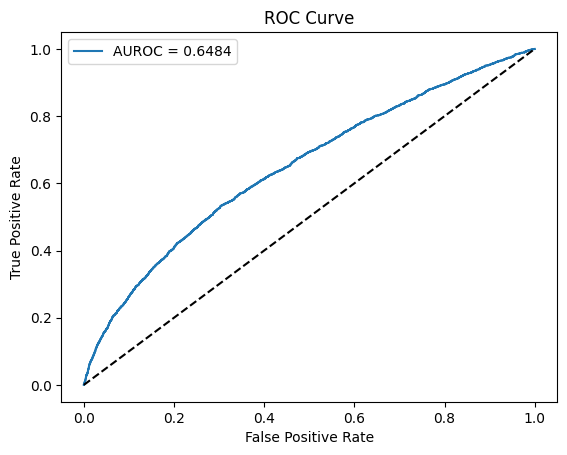

In [20]:
# AUROC Curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUROC = {auroc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [21]:
# Check class distribution in test set
print("Test set class distribution:")
print(y_test.value_counts(normalize=True))

# Quick prediction check (first batch)
with torch.no_grad():
    features, labels = next(iter(test_loader))
    features = features.to(device)
    outputs = model(features)
    probs = torch.sigmoid(outputs).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    print("Sample probability (first 10):", probs.flatten()[:10])
    print("Sample predictions (first 10):", preds.flatten()[:10])
    print("Sample true labels (first 10):", labels.cpu().numpy().flatten()[:10])

Test set class distribution:
Diabetes
0    0.89976
1    0.10024
Name: proportion, dtype: float64
Sample probability (first 10): [0.24741907 0.06937251 0.03313996 0.63026726 0.54482764 0.1665776
 0.5566542  0.02159266 0.24586476 0.00769539]
Sample predictions (first 10): [0 0 0 1 1 0 1 0 0 0]
Sample true labels (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
